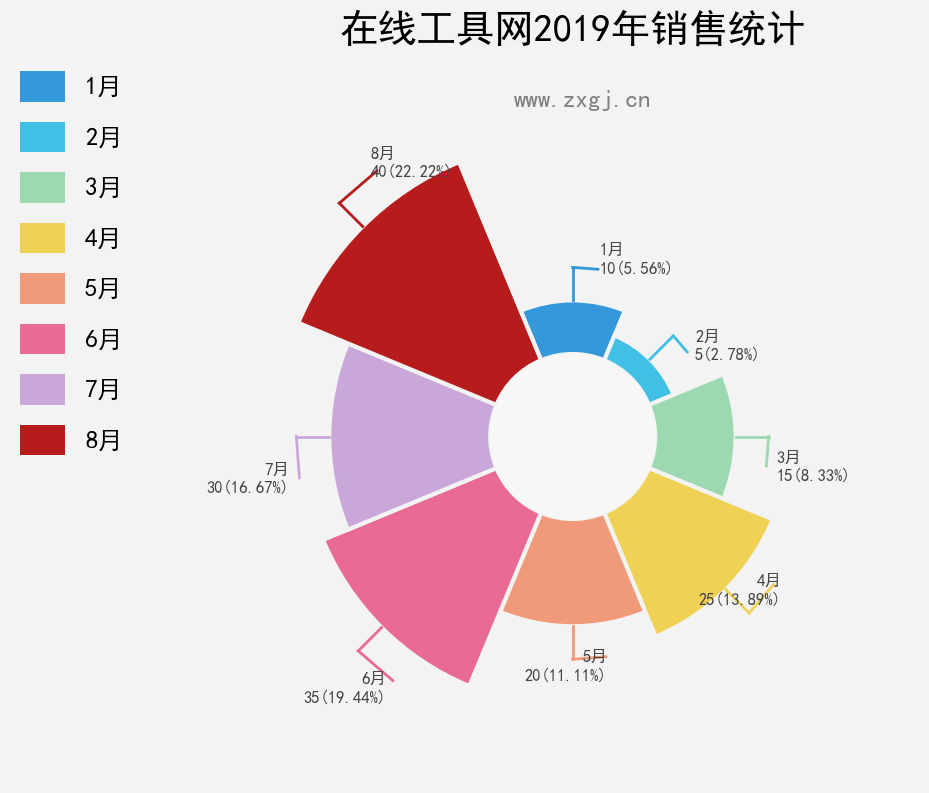

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================
# 中文字体
# ==========================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================
# 数据
# ==========================
months = ['1月','2月','3月','4月',
          '5月','6月','7月','8月']

values = np.array([10,5,15,25,20,35,30,40])

total = values.sum()

# ==========================
# 缩放（防止超出画布）
# ==========================
values_plot = values * 0.65

# ==========================
# 颜色
# 仅修改8月颜色
# ==========================
colors = [
    '#3498db',
    '#41c0e5',
    '#9dd9b0',
    '#efd255',
    '#f19a7a',
    '#e96b94',
    '#c9a7d9',
    '#b71c1c'      
]

# ==========================
# 角度
# ==========================
N = len(values)

theta = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
)

width = 2*np.pi/N

# ==========================
# 创建画布
# ==========================
fig = plt.figure(
    figsize=(14,9),
    facecolor='#f3f3f3'
)

ax = plt.subplot(111, polar=True)

ax.set_facecolor('#f3f3f3')

# 起始方向
ax.set_theta_offset(np.pi/2)

# 顺时针
ax.set_theta_direction(-1)

# ==========================
# 环形参数
# ==========================
inner_radius = 10

bars = ax.bar(
    theta,
    values_plot,
    width=width,
    bottom=inner_radius,
    color=colors,
    edgecolor='#f3f3f3',
    linewidth=3
)

# 防止裁切
ax.set_ylim(0, 42)

# ==========================
# 中间白色圆环
# ==========================
center_circle = plt.Circle(
    (0,0),
    inner_radius,
    transform=ax.transData._b,
    color='#f7f7f7',
    zorder=100
)

ax.add_artist(center_circle)

# ==========================
# 去坐标轴
# ==========================
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

try:
    ax.spines['polar'].set_visible(False)
except:
    pass

# ==========================
# 标签与引导线
# ==========================
for i,(angle,val,val_plot) in enumerate(
    zip(theta,values,values_plot)
):

    percent = val/total*100

    r_start = inner_radius + val_plot
    r_end = r_start + 4

    # 径向引导线
    ax.plot(
        [angle,angle],
        [r_start,r_end],
        color=colors[i],
        lw=2
    )

    # 水平引导线
    if np.cos(angle) >= 0:

        angle2 = angle + 0.15

        ax.plot(
            [angle,angle2],
            [r_end,r_end],
            color=colors[i],
            lw=2
        )

        ha='left'

        text_angle=angle2

    else:

        angle2 = angle - 0.15

        ax.plot(
            [angle,angle2],
            [r_end,r_end],
            color=colors[i],
            lw=2
        )

        ha='right'

        text_angle=angle2

    ax.text(
        text_angle,
        r_end+1.2,
        f"{months[i]}\n{val}({percent:.2f}%)",
        fontsize=12,
        color='#444444',
        ha=ha,
        va='center'
    )

# ==========================
# 图例
# ==========================
legend_elements = [
    Patch(facecolor=colors[i],label=months[i])
    for i in range(N)
]

plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(-0.33,0.75),
    frameon=False,
    fontsize=18,
    handlelength=1.8,
    handleheight=1.5,
    labelspacing=0.8
)

# ==========================
# 标题
# ==========================
plt.title(
    '在线工具网2019年销售统计',
    fontsize=28,
    fontweight='bold',
    pad=35
)

# 副标题
fig.text(
    0.52,
    0.86,
    'www.zxgj.cn',
    ha='center',
    fontsize=18,
    color='gray'
)

# ==========================
# 保存
# ==========================
plt.savefig(
    'rose_final.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='#f3f3f3'
)

plt.show()